# 作业2：使用 Qwen-VL 解析本地 PDF 第一页

## 流程
1. 用 `pymupdf (fitz)` 将 PDF 第一页**渲染为图片**
2. 将图片做 **Base64 编码**
3. 通过 **OpenAI 兼容接口**发送给 `qwen-vl-max-latest`
4. 打印模型返回的解析结果

> 参考文档：https://help.aliyun.com/zh/model-studio/visual-reasoning

In [1]:
# 安装依赖（首次运行）
%pip install pymupdf openai -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import base64
import io

import fitz                  # pymupdf
from openai import OpenAI
from IPython.display import display, Image as IPImage

print("依赖导入成功")

依赖导入成功


## 配置：PDF 路径 & 解析参数

In [3]:
# ── 配置区（按需修改）──────────────────────────────────
PDF_PATH   = r"D:\1_Project\llm_learning\第9周：Dify智能体搭建\Week09-Dify智能体搭建.pdf"
RENDER_DPI = 150      # 渲染分辨率，DPI 越高越清晰但 Token 消耗越多
PROMPT     = "请详细解析这张 PDF 页面的内容，包括文字、图表、标题结构等。"
API_KEY    = "sk-026bc9ed889740aa948ebf5b06ebbe99"
# ────────────────────────────────────────────────────────

print(f"PDF: {PDF_PATH}")
print(f"DPI: {RENDER_DPI}")
print(f"Prompt: {PROMPT}")

PDF: D:\1_Project\llm_learning\第9周：Dify智能体搭建\Week09-Dify智能体搭建.pdf
DPI: 150
Prompt: 请详细解析这张 PDF 页面的内容，包括文字、图表、标题结构等。


## Step 1：渲染 PDF 第一页为图片

In [7]:
def pdf_first_page_to_base64(pdf_path: str, dpi: int = 150) -> tuple[bytes, str]:
    """将 PDF 第一页渲染为 PNG，返回 (raw_bytes, base64_str)。"""
    doc = fitz.open(pdf_path)
    page = doc[0]                                  # 第一页（0-indexed）
    mat = fitz.Matrix(dpi / 72, dpi / 72)          # 72 DPI 是 PDF 基准分辨率
    pix = page.get_pixmap(matrix=mat, alpha=False) # 渲染为 RGB 位图
    buf = io.BytesIO(pix.tobytes("png"))
    doc.close()
    raw = buf.getvalue()
    return raw, base64.b64encode(raw).decode("utf-8")


print(f">>> 渲染 PDF 第一页（DPI={RENDER_DPI}）...")
img_bytes, img_b64 = pdf_first_page_to_base64(PDF_PATH, dpi=RENDER_DPI)
print(f"    图片大小: {len(img_bytes) / 1024:.1f} KB")
print(f"    Base64 大小: {len(img_b64):,} chars")

>>> 渲染 PDF 第一页（DPI=150）...
    图片大小: 43.7 KB
    Base64 大小: 59,696 chars


## 预览渲染结果

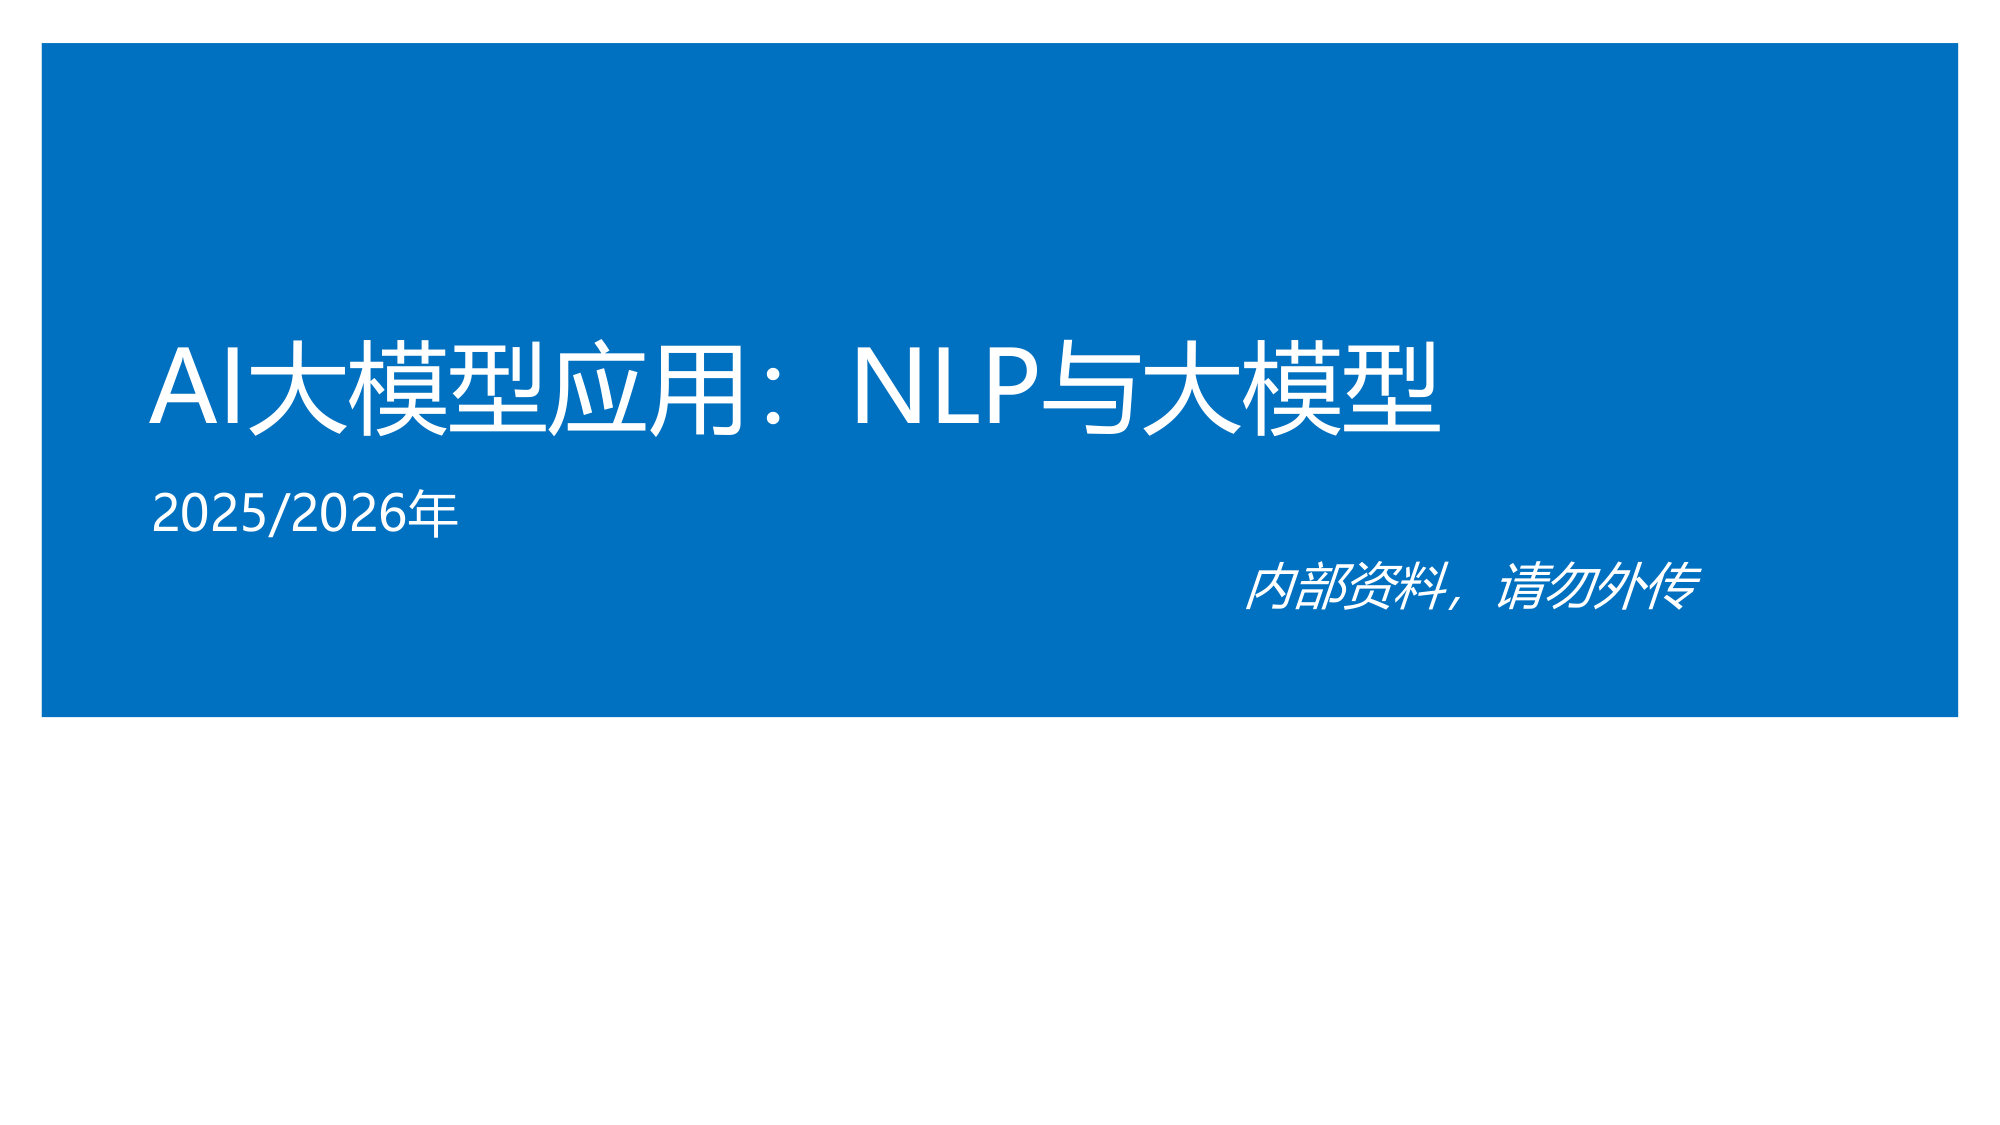

In [5]:
display(IPImage(data=img_bytes))

## Step 2：调用 Qwen-VL API

In [ ]:
client = OpenAI(
    api_key="sk-2d7basdads837bb6dasae4d3dasdadsa38db99583c22dc0d9",
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
)

print(">>> 调用 Qwen-VL API...")
response = client.chat.completions.create(
    model="qwen-vl-max-latest",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {
                        # base64 内联格式：data:<mime>;base64,<data>
                        "url": f"data:image/png;base64,{img_b64}"
                    },
                },
                {
                    "type": "text",
                    "text": PROMPT,
                },
            ],
        }
    ],
)
print("调用成功")

>>> 调用 Qwen-VL API...
调用成功


## Step 3：查看解析结果

In [11]:
result = response.choices[0].message.content

print("=" * 50)
print("Qwen-VL 解析结果")
print("=" * 50)
print(result)
print()
print(f"Token 用量 — 输入: {response.usage.prompt_tokens} | 输出: {response.usage.completion_tokens}")

Qwen-VL 解析结果
这张图片是一张 PDF 页面的封面或标题页，整体设计简洁明了，主要包含文字信息，无图表或其他视觉元素。以下是详细解析：

---

### **1. 整体布局与背景**
- **背景颜色**：页面主体为深蓝色矩形区域（RGB 色值约为 0, 92, 178），占据页面大部分空间。
- **边框**：蓝色区域四周有白色边距，形成清晰的视觉边界。
- **字体颜色**：所有文字均为白色，与蓝色背景形成高对比度，确保可读性。

---

### **2. 文字内容分析**

#### **主标题**
- **内容**：`AI大模型应用：NLP与大模型`
- **位置**：位于蓝色区域的左上部，居中对齐。
- **字体特征**：
  - 字体较大，可能是粗体（Bold）。
  - 使用中文黑体或类似无衬线字体，清晰现代。
- **含义**：
  - 主题明确：聚焦于人工智能（AI）中的“大模型”在自然语言处理（NLP）领域的应用。
  - “大模型”通常指参数量巨大的深度学习模型，如 GPT、BERT 等。
  - “NLP”是 Natural Language Processing 的缩写，即自然语言处理。

#### **副标题/时间标注**
- **内容**：`2025/2026年`
- **位置**：位于主标题下方，靠左对齐。
- **字体特征**：
  - 字体较小，非粗体。
  - 可能为常规字体（Regular）。
- **含义**：
  - 表明该文档可能涉及未来两年（2025–2026）的规划、预测或研究方向。
  - 或者是该资料的适用时间段。

#### **保密声明**
- **内容**：`内部资料，请勿外传`
- **位置**：位于蓝色区域右下角，靠右对齐。
- **字体特征**：
  - 字体较小，可能是斜体或普通字体。
  - 颜色略浅于其他文字（可能是半透明或更淡的白色），但仍可辨识。
- **含义**：
  - 明确提示该文档属于内部机密资料，禁止对外传播。
  - 常见于企业、研究机构或政府组织的内部报告。

---

### **3. 标题结构**
- **层级结构**：
  1. **一级标题**：`AI大模型应用：NLP与大模型` —— 核心主题。
  2. **二级信息**：`2025/2026年` ——